# Heart Disease Prediction Model

This notebook is used to perform:
- Exploratory Data Analysis (EDA)
- Proofs of Concept (PoCs) for multiple machine learning models
- Hyperparameter tuning and model evaluation

## Environment Setup

Create and activate a Python virtual environment:

```powershell
# Create virtual environment
Python3.11 -m venv .venv

# Activate virtual environment (Windows PowerShell)
.\.venv\Scripts\Activate.ps1

# Upgrade package management tools
python -m pip install --upgrade pip setuptools wheel

# Install project dependencies
uv pip install -r requirements.txt
```

> **Note:** Ensure that `uv` is installed before running the last command. If not, install it using:
>
> ```powershell
> pip install uv
> ```

## Dataset

#### Heart Disease UCI Dataset
- Source: UCI Machine Learning Repository https://archive.ics.uci.edu/ml/datasets/heart+Disease
- CSV containing 14+ features (age, sex, blood pressure, cholesterol, etc.) and a binary target (presence/absence of heart disease).

## Exploration & Data loading

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
from ucimlrepo import fetch_ucirepo

heart = fetch_ucirepo(id=45)

X = heart.data.features
y = heart.data.targets

df = pd.concat([X, y], axis=1)

df["target"] = (df["num"] > 0).astype(int)
df.drop(columns=["num"], inplace=True)

df.shape

(303, 14)

In [36]:
pd.set_option("display.max_columns", None)  # Show all columns in the DataFrame
pd.set_option("display.max_rows", None)  # Show all rows in the DataFrame

In [37]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [39]:
df.describe(include="all")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## Categorical Feature Encoding

Based on the output of `.describe()` and the exploratory data analysis (EDA), most categorical variables contain between **2 and 4 unique categories**.

- **Binary categorical variables (2 categories):**
  - Encode these variables as **0** and **1**.

- **Categorical variables with >2 categories:**
  - Apply **One-Hot Encoding** to create separate binary features for each category.

## Binary Encoding

In [40]:
# Binary categorical columns (2 unique values)
binary_cols = ["sex", "fbs", "exang", "target"]

df[binary_cols] = df[binary_cols].astype(bool)

In [41]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,True,1,145,233,True,2,150,False,2.3,3,0.0,6.0,False
1,67,True,4,160,286,False,2,108,True,1.5,2,3.0,3.0,True
2,67,True,4,120,229,False,2,129,True,2.6,2,2.0,7.0,True
3,37,True,3,130,250,False,0,187,False,3.5,3,0.0,3.0,False
4,41,False,2,130,204,False,2,172,False,1.4,1,0.0,3.0,False


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    bool   
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    bool   
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    bool   
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    bool   
dtypes: bool(4), float64(3), int64(7)
memory usage: 25.0 KB


## One-Hot encoding

In [43]:
# Categorical columns with > 2 unique values
multi_cat_cols = ["ca", "slope", "thal", "restecg", "cp"]

# One-hot encode
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [44]:
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,ca_1.0,ca_2.0,ca_3.0,slope_2,slope_3,thal_6.0,thal_7.0,restecg_1,restecg_2,cp_2,cp_3,cp_4
0,63,True,145,233,True,150,False,2.3,False,False,False,False,False,True,True,False,False,True,False,False,False
1,67,True,160,286,False,108,True,1.5,True,False,False,True,True,False,False,False,False,True,False,False,True
2,67,True,120,229,False,129,True,2.6,True,False,True,False,True,False,False,True,False,True,False,False,True
3,37,True,130,250,False,187,False,3.5,False,False,False,False,False,True,False,False,False,False,False,True,False
4,41,False,130,204,False,172,False,1.4,False,False,False,False,False,False,False,False,False,True,True,False,False


## Cleaning

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    int64  
 1   sex        303 non-null    bool   
 2   trestbps   303 non-null    int64  
 3   chol       303 non-null    int64  
 4   fbs        303 non-null    bool   
 5   thalach    303 non-null    int64  
 6   exang      303 non-null    bool   
 7   oldpeak    303 non-null    float64
 8   target     303 non-null    bool   
 9   ca_1.0     303 non-null    bool   
 10  ca_2.0     303 non-null    bool   
 11  ca_3.0     303 non-null    bool   
 12  slope_2    303 non-null    bool   
 13  slope_3    303 non-null    bool   
 14  thal_6.0   303 non-null    bool   
 15  thal_7.0   303 non-null    bool   
 16  restecg_1  303 non-null    bool   
 17  restecg_2  303 non-null    bool   
 18  cp_2       303 non-null    bool   
 19  cp_3       303 non-null    bool   
 20  cp_4      

In [46]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(
    int
)  # converts True/False to 1/0 for all boolean cols

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    int64  
 1   sex        303 non-null    int64  
 2   trestbps   303 non-null    int64  
 3   chol       303 non-null    int64  
 4   fbs        303 non-null    int64  
 5   thalach    303 non-null    int64  
 6   exang      303 non-null    int64  
 7   oldpeak    303 non-null    float64
 8   target     303 non-null    int64  
 9   ca_1.0     303 non-null    int64  
 10  ca_2.0     303 non-null    int64  
 11  ca_3.0     303 non-null    int64  
 12  slope_2    303 non-null    int64  
 13  slope_3    303 non-null    int64  
 14  thal_6.0   303 non-null    int64  
 15  thal_7.0   303 non-null    int64  
 16  restecg_1  303 non-null    int64  
 17  restecg_2  303 non-null    int64  
 18  cp_2       303 non-null    int64  
 19  cp_3       303 non-null    int64  
 20  cp_4      

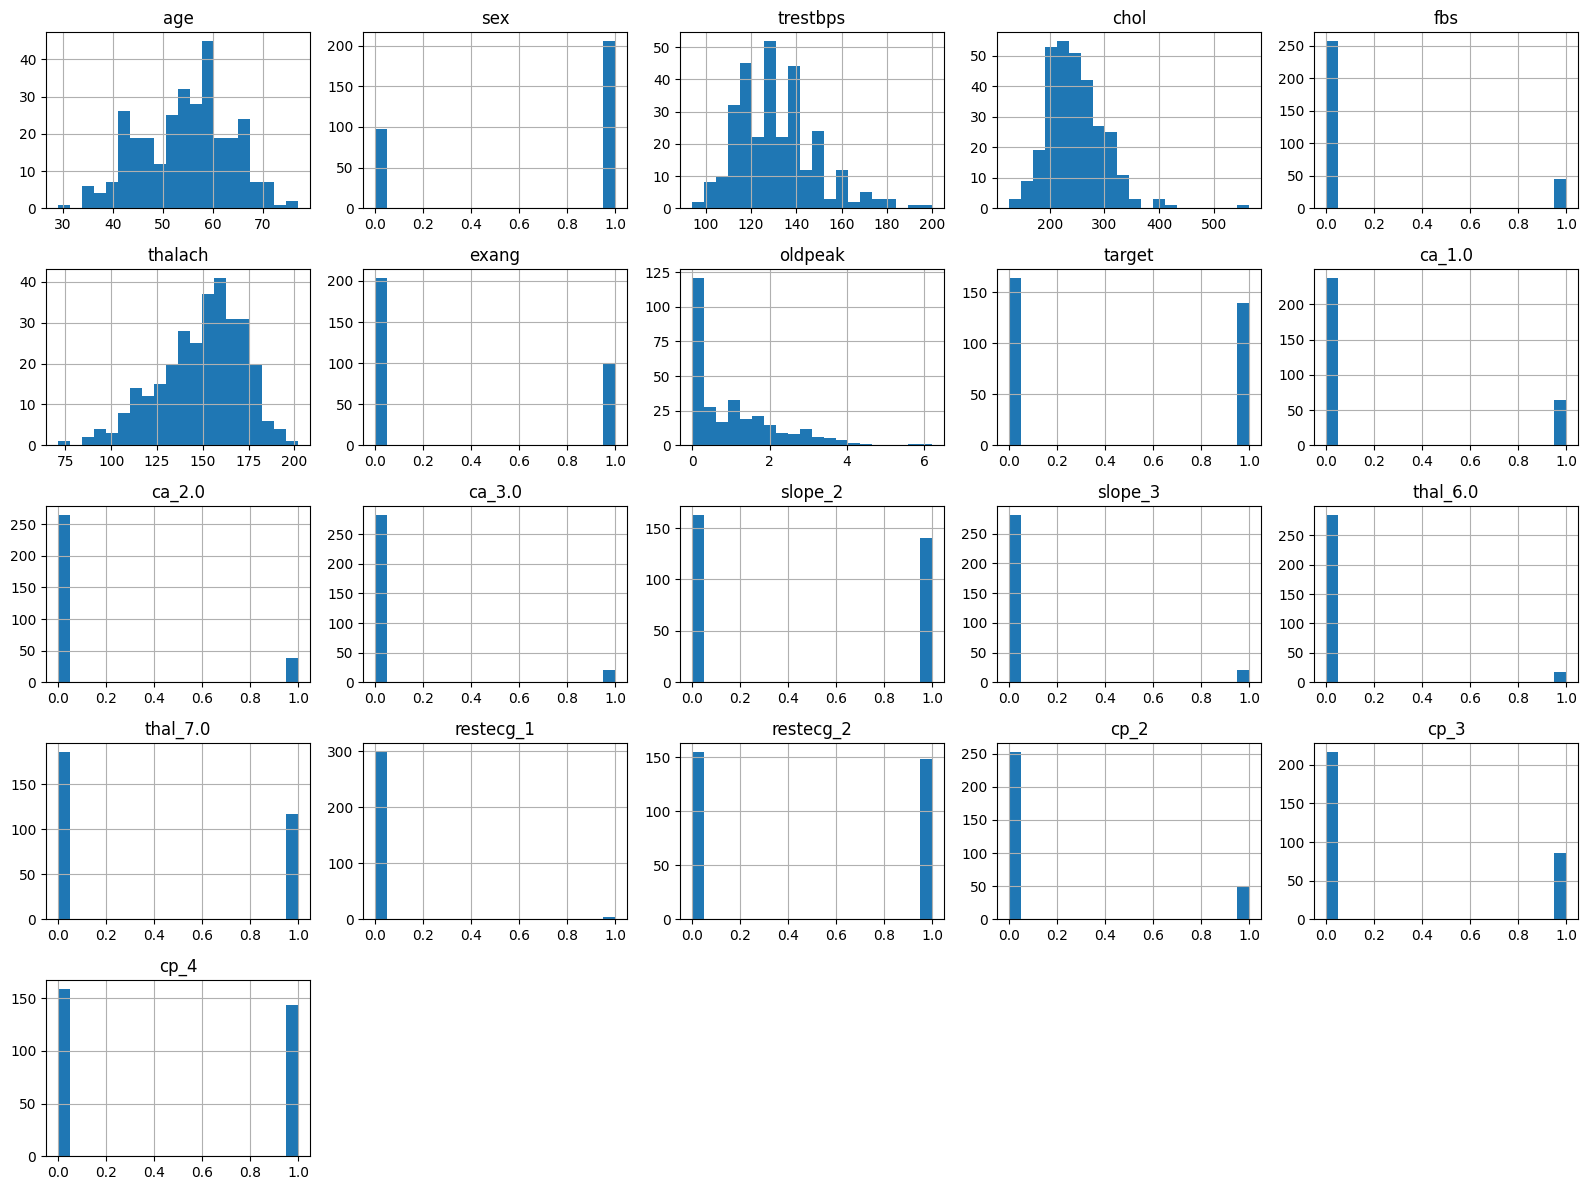

In [48]:
df.hist(figsize=(16, 12), bins=20)

plt.tight_layout()

In [49]:
corr_matrix = df.corr(numeric_only=True)
heartdisease_corr = corr_matrix["target"].sort_values(ascending=False)
print(heartdisease_corr)

target       1.000000
cp_4         0.516459
thal_7.0     0.480582
exang        0.431894
oldpeak      0.424510
slope_2      0.355709
sex          0.276816
ca_2.0       0.271334
ca_1.0       0.228818
age          0.223120
ca_3.0       0.208734
restecg_2    0.160400
trestbps     0.150825
thal_6.0     0.104864
chol         0.085164
restecg_1    0.067605
slope_3      0.061710
fbs          0.025264
cp_2        -0.248683
cp_3        -0.315141
thalach     -0.417167
Name: target, dtype: float64


## Key Observations

- The features with the strongest **positive correlation** with heart disease are:
  - **`cp_4`** – Asymptomatic chest pain
  - **`thal_7.0`** – Reversible defect
  - **`exang`** – Exercise-induced angina
  - **`oldpeak`** – ST depression induced by exercise

- The features with the strongest **negative correlation** with heart disease are:
  - **`thalach`** – Maximum heart rate achieved
  - **`cp_3`** – Non-anginal pain
  - **`cp_2`** – Atypical angina

- **Age** exhibits a moderate positive correlation (**0.223**) with the target, suggesting that although the risk of heart disease generally increases with age, it is not among the strongest individual predictors in this dataset.

- The variables **`cp_*`**, **`thal_*`**, **`ca_*`**, and **`slope_*`** are **one-hot encoded categorical features**. Their correlation values should be interpreted relative to the omitted reference category rather than as independent continuous variables.

- Features such as **`chol`** (cholesterol), **`fbs`** (fasting blood sugar), and **`trestbps`** (resting blood pressure) exhibit relatively weak linear correlations with the target. However, this does not necessarily imply they are unimportant, as they may contribute through **nonlinear relationships** or **feature interactions** that are better captured by tree-based models such as Random Forest, LightGBM, and XGBoost.

Text(0.5, 1.0, 'Feature Correlation')

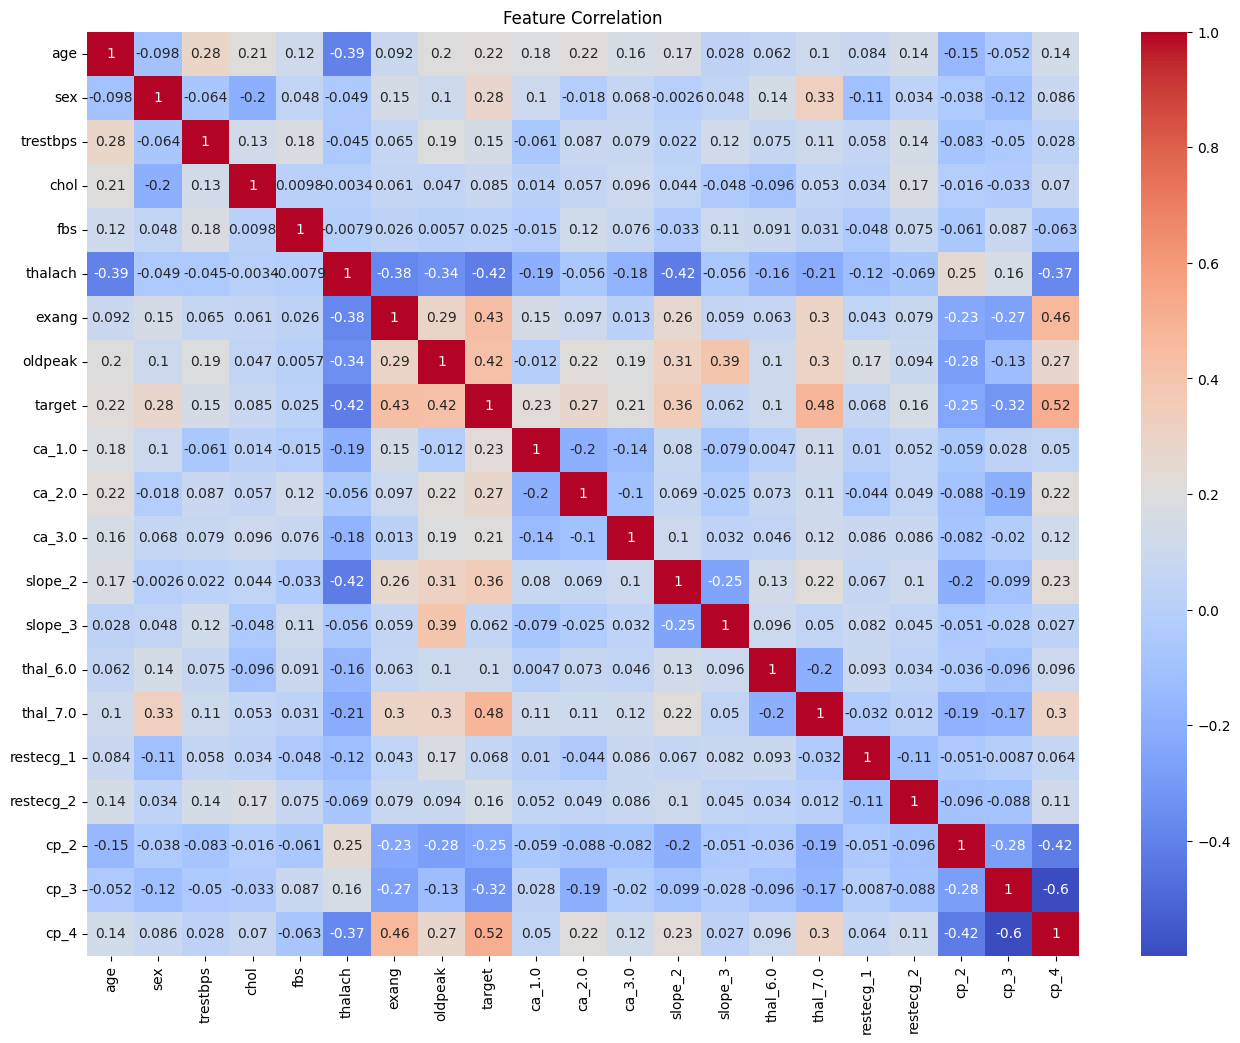

In [ ]:
# Compute correlation matrix only for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Focus on correlation with target variable
heartdisease_corr = corr_matrix[["target"]].sort_values(by="target", ascending=False)

# Plot heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
)

plt.title("Feature Correlation")

## Correlation Analysis

### Features Negatively Correlated with Heart Disease
The following feature is negatively correlated with the target variable, indicating that **higher values are associated with a lower likelihood of heart disease**:

| Feature | Correlation |
|---------|------------:|
| `thalach` | -0.417167 |

### Features Positively Correlated with Heart Disease
The following features are positively correlated with the target variable, indicating that **higher values are associated with a greater likelihood of heart disease**:

| Feature | Correlation |
|---------|------------:|
| `thal_7.0` | 0.480582 |
| `exang` | 0.431894 |
| `oldpeak` | 0.424510 |
| `cp` | 0.414446 |
| `slope_2` | 0.355709 |

> **Key Observations**
>
> - **`thalach` (maximum heart rate achieved)** shows the strongest negative correlation, suggesting that individuals with higher maximum heart rates are less likely to have heart disease.
> - **`thal_7.0`** exhibits the strongest positive correlation, indicating a strong association between this thalassemia category and heart disease.
> - **`exang` (exercise-induced angina)** and **`oldpeak` (ST depression induced by exercise)** are also strong positive indicators of heart disease.
> - **`cp` (chest pain type)** and **`slope_2` (flat ST segment slope)** show moderate positive correlations and contribute to predicting heart disease.

## Look for multicolinearity (VIF)

In [51]:
# Prepare X
X = df.drop(columns=["target"])
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

In [52]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

      feature        VIF
2    trestbps  60.616264
0         age  43.597899
5     thalach  40.123482
3        chol  26.897953
19       cp_4   7.209677
18       cp_3   4.582131
1         sex   3.955333
7     oldpeak   3.439748
17       cp_2   3.186077
11    slope_2   2.854330
14   thal_7.0   2.545683
16  restecg_2   2.181234
6       exang   2.173165
12    slope_3   1.680340
8      ca_1.0   1.614981
9      ca_2.0   1.552182
13   thal_6.0   1.339302
10     ca_3.0   1.314862
4         fbs   1.306742
15  restecg_1   1.114161


## Multicollinearity Analysis

The correlation analysis indicates the presence of **multicollinearity** among several predictor variables, meaning that some features are highly correlated with one another.

VIF < 5: Feature is generally safe to retain.
VIF > 5: Check whether the feature is redundant with others.
VIF > 10: Consider removing the feature or combining correlated variables.

### Key Observations

- The following continuous variables exhibit **very high VIF values**, indicating strong multicollinearity:
  - **`trestbps`** – 60.62
  - **`age`** – 43.60
  - **`thalach`** – 40.12
  - **`chol`** – 26.90

- The categorical feature **`cp_4`** has a moderately high VIF (**7.21**), suggesting some correlation with the other chest pain categories or related clinical features.

- Most of the remaining variables have **VIF values below 5**, indicating **low to moderate multicollinearity** and are generally not a concern.

- The one-hot encoded categorical variables (**`cp_*`**, **`ca_*`**, **`thal_*`**, **`slope_*`**, and **`restecg_*`**) exhibit acceptable VIF values, suggesting that the **dummy variable trap** has been successfully avoided by dropping one reference category during one-hot encoding.

### Implications

- Highly correlated features can negatively impact the performance and interpretability of certain models, particularly **linear** and **logistic regression**.
- Multicollinearity may lead to unstable coefficient estimates, making it difficult to assess the individual contribution of each feature.

### Possible Approaches

- **Remove redundant features** to reduce multicollinearity.
- **Apply regularization techniques**, such as:
  - **Lasso (L1) Regression** – Performs feature selection by shrinking some coefficients to zero.
  - **Ridge (L2) Regression** – Reduces coefficient variance by shrinking correlated feature weights.
- **Use tree-based models**, such as Decision Trees, Random Forests, or Gradient Boosting models (e.g., XGBoost and LightGBM), which are generally less sensitive to multicollinearity.

> **Note:** Tree-based models determine splits based on the feature that provides the greatest reduction in impurity. As a result, correlated features typically compete with one another during the splitting process rather than causing unstable predictions, making these models more robust to multicollinearity.

- In our case, as we will see further ahead, we will end up choosing a tree based model - XGBoost

## Machine learning Model Devlopment

In [53]:
# We have a small class imbalance problem
# Given your imbalance (20%), class weighting + threshold tuning is probably enough — no need for aggressive oversampling yet.
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

## Why Recall Is the Most Important Metric for Heart Disease Prediction

In heart disease prediction, **Recall** (and metrics derived from it, such as the **F1-score**) is typically considered the most important evaluation metric because the cost of missing a patient with heart disease is significantly higher than incorrectly identifying a healthy patient as high risk.

### Why Recall Matters

Recall measures the proportion of actual heart disease cases that are correctly identified by the model.

\[
\text{Recall} = \frac{TP}{TP + FN}
\]

where:

- **TP (True Positives):** Patients correctly identified as having heart disease.
- **FN (False Negatives):** Patients with heart disease that the model incorrectly classifies as healthy.

A **high recall** minimizes the number of **false negatives**, ensuring that as many patients with heart disease as possible are detected.

### Importance in Healthcare

- Missing a patient with heart disease (**false negative**) may delay diagnosis and treatment, potentially leading to severe health complications or death.
- Incorrectly identifying a healthy patient as high risk (**false positive**) typically results in additional diagnostic tests, which, while inconvenient and costly, are generally less harmful than overlooking an actual disease.

### Role of the F1-Score

While maximizing recall is often the primary objective, **Precision** should not be ignored. Excessively high recall can lead to many false positives.

The **F1-score** provides a balanced evaluation by combining both precision and recall:

\[
\text{F1-score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
\]

A high F1-score indicates that the model effectively identifies patients with heart disease while maintaining a reasonable false-positive rate.

> **Key Takeaway:** In heart disease prediction, prioritizing **Recall** helps ensure that patients with the disease are not missed. The **F1-score** is a valuable complementary metric because it balances the trade-off between identifying as many true cases as possible and limiting false alarms.

## Evaluation Metric Priorities

The choice of evaluation metric should align with the objectives of the heart disease prediction system.

### Typical Priorities

1. **Prioritize Recall**
   - Maximize **Recall** to identify as many patients with heart disease as possible.
   - Minimizing **false negatives** is critical, as missed diagnoses can have serious clinical consequences.

2. **Balance Precision and Recall**
   - Use the **F1-score** or analyze the **Precision–Recall trade-off** to achieve a balance between detecting true cases and limiting false positives.

3. **Evaluate Ranking Performance**
   - If the goal is to rank patients by their risk of heart disease rather than make binary predictions, use **ROC-AUC** or **Precision–Recall AUC (PR-AUC)** to assess the model's discriminative ability across different classification thresholds.

> **Recommendation:** For heart disease prediction, **Recall** should generally be the primary optimization objective, with the **F1-score** and **ROC-AUC/PR-AUC** serving as complementary metrics for overall model evaluation.

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd
import time

# Prepare data
X = df.drop(columns=["target"])
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

THRESHOLD = 0.3  # lower than 0.5 to boost recall (see next to choose the right value)

### RandomForest Classifier

In [55]:
import mlflow
import mlflow.sklearn
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Force MLflow to always use the project root's mlruns folder
from pathlib import Path

project_root = Path.cwd().resolve().parent

tracking_uri = f"file:///{project_root / 'mlruns'}"
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("Model Comparison")

print("Tracking URI:", mlflow.get_tracking_uri())

print(os.getcwd())

# Enable autologging
# mlflow.sklearn.autolog(log_models=False, log_input_examples=True)

rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
)

with mlflow.start_run(run_name="RandomForestClassifier"):
    # ------------------------
    # Train
    # ------------------------
    start_train = time.time()
    rf.fit(X_train, y_train)
    train_time = time.time() - start_train

    # ------------------------
    # Predict
    # ------------------------
    start_pred = time.time()

    proba = rf.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)

    pred_time = time.time() - start_pred

    # ------------------------
    # Metrics
    # ------------------------
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, proba)

    print(f"Training time : {train_time:.2f} sec")
    print(f"Inference time: {pred_time:.4f} sec\n")

    print(classification_report(y_test, y_pred, digits=3))

    # ------------------------
    # Manual logging
    # ------------------------
    mlflow.log_param("threshold", THRESHOLD)

    mlflow.log_metric("train_time_sec", train_time)
    mlflow.log_metric("prediction_time_sec", pred_time)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix")
    print(cm)

    # Save classification report
    report = classification_report(y_test, y_pred, digits=3)

    with open("classification_report.txt", "w") as f:
        f.write(report)

    mlflow.log_artifact("classification_report.txt")
    # Delete the local file
    os.remove("classification_report.txt")

    # Save confusion matrix
    import matplotlib.pyplot as plt

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.xticks([0, 1], ["No Disease", "Disease"])
    plt.yticks([0, 1], ["No Disease", "Disease"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.close()

    mlflow.log_artifact("confusion_matrix.png")

    # Delete the local file
    os.remove("confusion_matrix.png")

    # # Log model
    model_info = mlflow.sklearn.log_model(sk_model=rf, artifact_path="model")

    print(model_info)
    print(model_info.model_uri)

    run = mlflow.active_run()

    print(run.info.run_id)
    print(run.info.artifact_uri)

Tracking URI: file:///C:\Users\naras\Work\WILP\MLOPS\Assignment1\HeartDiseasePredictor\mlruns
c:\Users\naras\Work\WILP\MLOPS\Assignment1\HeartDiseasePredictor\notebooks


2026/07/11 04:42:20 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\naras\Work\WILP\MLOPS\Assignment1\HeartDiseasePredictor\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/07/11 04:42:24 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\

Training time : 3.17 sec
Inference time: 0.1957 sec

              precision    recall  f1-score   support

           0      1.000     0.697     0.821        33
           1      0.737     1.000     0.848        28

    accuracy                          0.836        61
   macro avg      0.868     0.848     0.835        61
weighted avg      0.879     0.836     0.834        61


Confusion Matrix
[[23 10]
 [ 0 28]]


2026/07/11 04:42:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 04:42:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


models:/m-aac382f19d914c6a854402f99370838c
a61c8c28210143c6b1c13de3ee2b56b2
file:///C:\Users\naras\Work\WILP\MLOPS\Assignment1\HeartDiseasePredictor\mlruns/763944226561289849/a61c8c28210143c6b1c13de3ee2b56b2/artifacts


In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

2026/07/11 04:42:33 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\naras\Work\WILP\MLOPS\Assignment1\HeartDiseasePredictor\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.718   1.000   0.836   
0.3     0.737   1.000   0.848   
0.35    0.778   1.000   0.875   
0.4     0.818   0.964   0.885   
0.45    0.844   0.964   0.900   
0.5     0.844   0.964   0.900   


### LightGBM classifier

In [57]:
import time
import mlflow
import mlflow.sklearn
import os
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Force MLflow to always use the project root's mlruns folder
mlflow.set_experiment("Model Comparison")

# =====================================================
# LightGBM Parameters
# =====================================================
params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

# Build model
lgbm = LGBMClassifier(**params)

with mlflow.start_run(run_name="LightGBM"):
    # Log hyperparameters
    mlflow.log_params(params)
    mlflow.log_param("threshold", THRESHOLD)

    # ==========================
    # Train
    # ==========================
    start_train = time.time()
    lgbm.fit(X_train, y_train)
    train_time = time.time() - start_train
    print(f"⏱ Training time: {train_time:.2f} seconds")

    # ==========================
    # Predict
    # ==========================
    start_pred = time.time()

    proba = lgbm.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)

    pred_time = time.time() - start_pred
    print(f"Prediction Time: {pred_time:.4f} sec")

    # ------------------------
    # Metrics
    # ------------------------
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, proba)

    print(f"Training time : {train_time:.2f} sec")
    print(f"Inference time: {pred_time:.4f} sec\n")

    print(classification_report(y_test, y_pred, digits=3))

    # ------------------------
    # Manual logging
    # ------------------------
    mlflow.log_param("threshold", THRESHOLD)

    mlflow.log_metric("train_time_sec", train_time)
    mlflow.log_metric("prediction_time_sec", pred_time)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix")
    print(cm)

    # Save classification report
    report = classification_report(y_test, y_pred, digits=3)

    with open("classification_report.txt", "w") as f:
        f.write(report)

    mlflow.log_artifact("classification_report.txt")

    # Delete the local file
    os.remove("classification_report.txt")

    # Save confusion matrix
    import matplotlib.pyplot as plt

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.xticks([0, 1], ["No Disease", "Disease"])
    plt.yticks([0, 1], ["No Disease", "Disease"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.close()

    mlflow.log_artifact("confusion_matrix.png")

    # Delete the local file
    os.remove("confusion_matrix.png")

    # Log model
    mlflow.sklearn.log_model(lgbm, name="model")

⏱ Training time: 1.10 seconds
Prediction Time: 0.0046 sec
Training time : 1.10 sec
Inference time: 0.0046 sec

              precision    recall  f1-score   support

           0      0.962     0.758     0.847        33
           1      0.771     0.964     0.857        28

    accuracy                          0.852        61
   macro avg      0.866     0.861     0.852        61
weighted avg      0.874     0.852     0.852        61


Confusion Matrix
[[25  8]
 [ 1 27]]


2026/07/11 04:42:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [58]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = lgbm.predict_proba(X_test)[:, 1]

print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.757   1.000   0.862   
0.3     0.771   0.964   0.857   
0.35    0.765   0.929   0.839   
0.4     0.812   0.929   0.867   
0.45    0.806   0.893   0.847   
0.5     0.821   0.821   0.821   


### XGBoost Classifier

In [59]:
import os
import time
import mlflow
import mlflow.xgboost

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

mlflow.set_experiment("Model Comparison")

# -------------------------------------------------------
# MLflow Setup
# -------------------------------------------------------

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
)

with mlflow.start_run(run_name="XGBoost"):
    # Log hyperparameters
    mlflow.log_params(
        {
            "n_estimators": 500,
            "learning_rate": 0.05,
            "max_depth": 6,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "scale_pos_weight": float(scale_pos_weight),
            "threshold": THRESHOLD,
            "random_state": 42,
        }
    )

    # Log hyperparameters
    mlflow.log_params(params)
    mlflow.log_param("threshold", THRESHOLD)

    # ==========================
    # Train
    # ==========================
    start_train = time.time()
    xgb.fit(X_train, y_train)
    train_time = time.time() - start_train
    print(f"⏱ Training time: {train_time:.2f} seconds")

    # ==========================
    # Predict
    # ==========================
    start_pred = time.time()

    proba = xgb.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)

    pred_time = time.time() - start_pred
    print(f"Prediction Time: {pred_time:.4f} sec")

    # ------------------------
    # Metrics
    ## ------------------------
    # Metrics
    # ------------------------
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, proba)

    print(f"Training time : {train_time:.2f} sec")
    print(f"Inference time: {pred_time:.4f} sec\n")

    print(classification_report(y_test, y_pred, digits=3))

    # ------------------------
    # Manual logging
    # ------------------------
    mlflow.log_param("threshold", THRESHOLD)

    mlflow.log_metric("train_time_sec", train_time)
    mlflow.log_metric("prediction_time_sec", pred_time)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix")
    print(cm)

    # Save classification report
    report = classification_report(y_test, y_pred, digits=3)

    with open("classification_report.txt", "w") as f:
        f.write(report)

    mlflow.log_artifact("classification_report.txt")

    # Delete the local file
    os.remove("classification_report.txt")

    # Save confusion matrix
    import matplotlib.pyplot as plt

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.xticks([0, 1], ["No Disease", "Disease"])
    plt.yticks([0, 1], ["No Disease", "Disease"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.close()

    mlflow.log_artifact("confusion_matrix.png")

    # Delete the local file
    os.remove("confusion_matrix.png")

    # Log model
    mlflow.xgboost.log_model(xgb, name="model")

⏱ Training time: 0.77 seconds
Prediction Time: 0.0101 sec
Training time : 0.77 sec
Inference time: 0.0101 sec

              precision    recall  f1-score   support

           0      1.000     0.818     0.900        33
           1      0.824     1.000     0.903        28

    accuracy                          0.902        61
   macro avg      0.912     0.909     0.902        61
weighted avg      0.919     0.902     0.901        61


Confusion Matrix
[[27  6]
 [ 0 28]]


c:\Users\naras\Work\WILP\MLOPS\Assignment1\HeartDiseasePredictor\.venv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [04:42:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2026/07/11 04:42:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(X_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.778   1.000   0.875   
0.3     0.824   1.000   0.903   
0.35    0.848   1.000   0.918   
0.4     0.844   0.964   0.900   
0.45    0.844   0.964   0.900   
0.5     0.839   0.929   0.881   


In [61]:
import mlflow
from mlflow.tracking import MlflowClient

client = MlflowClient()

experiment = mlflow.get_experiment_by_name("Model Comparison")

runs = client.search_runs(experiment_ids=[experiment.experiment_id])

best_run = None
best_score = -1

for run in runs:
    recall = run.data.metrics.get("recall", 0)
    f1 = run.data.metrics.get("f1", 0)

    score = 0.7 * recall + 0.3 * f1

    if score > best_score:
        best_score = score
        best_run = run

print("Best Run:", best_run.data.tags.get("mlflow.runName"))
print("Run ID:", best_run.info.run_id)
print("Combined Score:", best_score)
print(best_run.data.metrics)

model_uri = f"runs:/{best_run.info.run_id}/model"

Best Run: XGBoost
Run ID: 7f9c2c1828ac45818fa7b1f426b85442
Combined Score: 0.7
{'accuracy': 0.9016393442622951, 'f1_score': 0.9032258064516129, 'precision': 0.8235294117647058, 'prediction_time_sec': 0.010051965713500977, 'recall': 1.0, 'roc_auc': 0.9274891774891775, 'train_time_sec': 0.7693493366241455}


### ML model choice - XGBoost
- Gives higher recall and F1 score vs other two models
- Faster to train (10x faster than Random Forest)

## Hyperparameter Tuning (Optuna) & Experiment Tracking (MLFlow)

In [62]:
import os
import optuna
import mlflow
import mlflow.xgboost

from xgboost import XGBClassifier
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    classification_report,
)
from sklearn.model_selection import train_test_split

# -------------------------------------------------------------------
# MLflow Configuration
# -------------------------------------------------------------------
mlflow.set_experiment("XGBoost - Hyperparameter tuning with Optuna")

# -------------------------------------------------------------------
# Validation split (DO NOT USE TEST SET FOR TUNING)
# -------------------------------------------------------------------
X_train_opt, X_valid, y_train_opt, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)


# -------------------------------------------------------------------
# Optuna Objective
# -------------------------------------------------------------------
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 10),
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "logloss",
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
    }

    # Nested MLflow run for every Optuna trial
    with mlflow.start_run(run_name=f"Trial_{trial.number}", nested=True):
        mlflow.log_params(params)

        model = XGBClassifier(**params)

        model.fit(X_train_opt, y_train_opt)

        proba = model.predict_proba(X_valid)[:, 1]
        y_pred = (proba >= THRESHOLD).astype(int)

        recall = recall_score(y_valid, y_pred)
        precision = precision_score(y_valid, y_pred)
        f1 = f1_score(y_valid, y_pred)
        accuracy = accuracy_score(y_valid, y_pred)
        auc = roc_auc_score(y_valid, proba)

        mlflow.log_metric("Recall", recall)
        mlflow.log_metric("Precision", precision)
        mlflow.log_metric("F1", f1)
        mlflow.log_metric("Accuracy", accuracy)
        mlflow.log_metric("ROC_AUC", auc)

        return recall


# -------------------------------------------------------------------
# Parent MLflow Run
# -------------------------------------------------------------------
with mlflow.start_run(run_name="Optuna_XGBoost"):
    study = optuna.create_study(direction="maximize")

    study.optimize(objective, n_trials=30)

    print("\nBest Parameters")
    print(study.best_params)

    print("\nBest Recall")
    print(study.best_value)

    # ---------------------------------------------------------------
    # Train Best Model on Entire Training Data
    # ---------------------------------------------------------------
    best_params = study.best_params

    best_model = XGBClassifier(
        **best_params,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    )

    best_model.fit(X_train, y_train)

    # ---------------------------------------------------------------
    # Final Test Evaluation
    # ---------------------------------------------------------------
    proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, proba)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # ---------------------------------------------------------------
    # Log Best Model
    # ---------------------------------------------------------------
    mlflow.log_params(best_params)

    mlflow.log_metric("Accuracy", accuracy)
    mlflow.log_metric("Precision", precision)
    mlflow.log_metric("Recall", recall)
    mlflow.log_metric("F1", f1)
    mlflow.log_metric("ROC_AUC", roc_auc)

    mlflow.xgboost.log_model(best_model, name="model")

    # Optional: save the Optuna study as an artifact
    with open("best_params.txt", "w") as f:
        f.write(str(study.best_params))

    mlflow.log_artifact("best_params.txt")

    # Delete the local file
    os.remove("best_params.txt")

print("\nOptimization Complete!")

[I 2026-07-11 04:42:55,546] A new study created in memory with name: no-name-4385193a-9cec-4b3a-aeb4-9472c1ccd253
[I 2026-07-11 04:42:56,473] Trial 0 finished with value: 0.9090909090909091 and parameters: {'n_estimators': 532, 'learning_rate': 0.07275355825195065, 'max_depth': 9, 'subsample': 0.7568843396466277, 'colsample_bytree': 0.618808677515777, 'min_child_weight': 9, 'gamma': 0.7906293928084718, 'reg_alpha': 4.90944421520261, 'reg_lambda': 8.008863778016337}. Best is trial 0 with value: 0.9090909090909091.
[I 2026-07-11 04:42:57,684] Trial 1 finished with value: 0.9090909090909091 and parameters: {'n_estimators': 683, 'learning_rate': 0.03663132820174051, 'max_depth': 5, 'subsample': 0.7409892633370344, 'colsample_bytree': 0.8046852891985017, 'min_child_weight': 5, 'gamma': 0.5157484785639344, 'reg_alpha': 0.9021506201442958, 'reg_lambda': 2.7054757075387994}. Best is trial 0 with value: 0.9090909090909091.
[I 2026-07-11 04:42:58,719] Trial 2 finished with value: 0.8636363636363


Best Parameters
{'n_estimators': 532, 'learning_rate': 0.07275355825195065, 'max_depth': 9, 'subsample': 0.7568843396466277, 'colsample_bytree': 0.618808677515777, 'min_child_weight': 9, 'gamma': 0.7906293928084718, 'reg_alpha': 4.90944421520261, 'reg_lambda': 8.008863778016337}

Best Recall
0.9090909090909091

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.61      0.75        33
           1       0.68      1.00      0.81        28

    accuracy                           0.79        61
   macro avg       0.84      0.80      0.78        61
weighted avg       0.85      0.79      0.78        61



c:\Users\naras\Work\WILP\MLOPS\Assignment1\HeartDiseasePredictor\.venv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [04:43:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2026/07/11 04:43:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Optimization Complete!


In [ ]:
import mlflow

# import mlflow.sklearn
import mlflow.xgboost
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import time
import os
from mlflow.artifacts import download_artifacts


# Force MLflow to always use the project root's mlruns folder
from pathlib import Path

import shutil
from pathlib import Path
import mlflow
import mlflow.xgboost

project_root = Path(os.getcwd()).parent
mlruns_path = project_root / "mlruns"

mlruns_path.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(mlruns_path.resolve().as_uri())
mlflow.set_experiment("Heart Disease Prediction Model")

with mlflow.start_run(run_name="Candidate Model"):
    # Calculate scale_pos_weight
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # Best params from Optuna
    best_params = study.best_params
    best_params.update(
        {
            "random_state": 42,
            "n_jobs": -1,
            "scale_pos_weight": scale_pos_weight,
            "eval_metric": "logloss",
        }
    )

    # Log parameters
    mlflow.log_params(best_params)

    # Training timer
    start_train = time.time()
    xgb = XGBClassifier(**best_params)
    xgb.fit(X_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)

    # Prediction
    start_pred = time.time()
    proba = xgb.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)

    # Metrics
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    # # Save model
    # model_info = mlflow.xgboost.log_model(
    #     xgb_model=xgb,
    #     name="candidate_model"
    # )

    # print(model_info.model_uri)

    # # Optional raw model
    # xgb.save_model("HeartDiseasePredictor.json")
    # mlflow.log_artifact(
    #     "HeartDiseasePredictor.json",
    #     artifact_path="candidate_model"
    # )
    # os.remove("HeartDiseasePredictor.json")

    MODEL_NAME = "HeartDiseasePredictor"

    # ---------------------------------------------------
    # 1. Log MLflow Model
    # ---------------------------------------------------
    model_info = mlflow.xgboost.log_model(xgb_model=xgb, name="candidate_model")

    print(f"Model URI: {model_info.model_uri}")

    # ---------------------------------------------------
    # 2. Save native XGBoost JSON as artifact
    # ---------------------------------------------------
    json_file = f"{MODEL_NAME}.json"

    xgb.save_model(json_file)

    mlflow.log_artifact(json_file, artifact_path="candidate_model")

    os.remove(json_file)

    # ---------------------------------------------------
    # 3. Register Model
    # ---------------------------------------------------
    registered_model = mlflow.register_model(
        model_uri=model_info.model_uri, name=MODEL_NAME
    )

    print(f"Registered {registered_model.name} Version {registered_model.version}")

    # ---------------------------------------------------
    # 4. Download Registered Model
    # ---------------------------------------------------
    registered_model_uri = f"models:/{MODEL_NAME}/{registered_model.version}"

    downloaded_model = download_artifacts(artifact_uri=registered_model_uri)

    # ---------------------------------------------------
    # 5. Download Run Artifacts
    # ---------------------------------------------------
    run_artifacts = download_artifacts(
        artifact_uri=f"runs:/{model_info.run_id}/candidate_model"
    )

    # ---------------------------------------------------
    # 6. Prepare Serving Directory
    # ---------------------------------------------------
    serving_dir = os.path.join("..", "serving")

    if os.path.exists(serving_dir):
        shutil.rmtree(serving_dir)

    os.makedirs(serving_dir)

    # Copy run artifacts
    shutil.copytree(run_artifacts, os.path.join(serving_dir, "model"))

    print(f"Serving model available at: {serving_dir}")

    print(classification_report(y_test, y_pred, digits=3))

c:\Users\naras\Work\WILP\MLOPS\Assignment1\HeartDiseasePredictor\.venv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [08:08:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2026/07/11 08:08:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model URI: models:/m-14c186262a9a45c1bed41ce3931ea234


Registered model 'HeartDiseasePredictor' already exists. Creating a new version of this model...
Created version '8' of model 'HeartDiseasePredictor'.


Registered HeartDiseasePredictor Version 8


Serving model available at: ..\serving\model
              precision    recall  f1-score   support

           0      1.000     0.606     0.755        33
           1      0.683     1.000     0.812        28

    accuracy                          0.787        61
   macro avg      0.841     0.803     0.783        61
weighted avg      0.854     0.787     0.781        61

